In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import KFold

from gap.classifiers import SmallCNN, train_cnn
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

train_data = datasets.CIFAR10(
    root="../datasets", train=True, download=True, transform=transform
)
test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

In [2]:
from itertools import product

coarse_space = {
    "lr": [1e-4, 1e-3, 1e-2],
    "channels": [16, 32, 64],
    "depth": [1, 2, 3],
    "opt": ["sgd", "adam"],
}


def coarse_sensitivity(train_subset, num_classes=10):
    results = []
    loader = DataLoader(train_subset, batch_size=128, shuffle=True)
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    for lr, ch, depth, opt in product(*coarse_space.values()):
        model = SmallCNN(num_classes=num_classes, channels=ch, depth=depth).to(device)

        trained_model, history = train_cnn(
            model=model,
            train_loader=loader,
            val_loader=loader,
            epochs=1,
            learning_rate=lr,
            device=device,
            optimizer_type=opt,
        )

        # extract the training accuracy from the history dictionary
        # since epochs=1, we just grab the first item [0] in the train_acc list
        acc = history["train_acc"][0]

        results.append(((lr, ch, depth, opt), acc))
        print(f"Params: {(lr, ch, depth, opt)} | Acc: {acc:.4f}\n")

    return sorted(results, key=lambda x: x[1], reverse=True)

In [6]:
subset_idx = np.random.choice(len(train_data), 5000, replace=False)
train_subset = Subset(train_data, subset_idx)

coarse_results = coarse_sensitivity(train_subset)

Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.3153 Acc: 0.0970 | Val Loss: 2.3153 Acc: 0.0972
   Validation accuracy improved to 0.0972!

Training Complete. Restoring best model weights (Val Acc: 0.0972)
Params: (0.0001, 16, 1, 'sgd') | Acc: 0.0970

Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.3021 Acc: 0.0868 | Val Loss: 2.2980 Acc: 0.0870
   Validation accuracy improved to 0.0870!

Training Complete. Restoring best model weights (Val Acc: 0.0870)
Params: (0.0001, 16, 1, 'adam') | Acc: 0.0868

Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.3068 Acc: 0.1220 | Val Loss: 2.3068 Acc: 0.1220
   Validation accuracy improved to 0.1220!

Training Complete. Restoring best model weights (Val Acc: 0.1220)
Params: (0.0001, 16, 2, 'sgd') | Acc: 0.1220

Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.3089 Acc: 0.1338 | Val Loss: 2.3033 Acc: 0.1504
   Validation accuracy improved to 0.1504!

Training Complete. Restoring best m

In [7]:
def derive_refined_space(coarse_results, top_frac=0.2):
    # coarse_results is: [((lr, channels, depth, opt), acc), ...]
    top_k = int(len(coarse_results) * top_frac)

    # take top-performing configs
    top_configs = [cfg for (cfg, acc) in coarse_results[:top_k]]

    # unpack each hyperparameter dimension
    lrs = [cfg[0] for cfg in top_configs]
    channels = [cfg[1] for cfg in top_configs]
    depths = [cfg[2] for cfg in top_configs]
    opts = [cfg[3] for cfg in top_configs]

    # build refined search space
    refined_space = {
        "lr": (min(lrs), max(lrs)),  # continuous range
        "channels": sorted(set(channels)),  # categorical
        "depth": sorted(set(depths)),  # categorical
        "opt": sorted(set(opts)),  # categorical
    }

    return refined_space

In [8]:
refined_space = derive_refined_space(coarse_results)
print(refined_space)

{'lr': (0.001, 0.01), 'channels': [16, 32, 64], 'depth': [1, 2, 3], 'opt': ['adam']}


In [9]:
import random

# refined_space = {
#    "lr": (5e-4, 5e-3),
#    "channels": [32, 48, 64],
#    "depth": [2, 3],
#    "opt": ["adam"]
# }


def sample_config():
    return {
        "lr": 10
        ** np.random.uniform(
            np.log10(refined_space["lr"][0]), np.log10(refined_space["lr"][1])
        ),
        "channels": random.choice(refined_space["channels"]),
        "depth": random.choice(refined_space["depth"]),
        "opt": "adam",
    }

In [10]:
def cross_val_score(config, train_subset, num_classes=10, k=3, device="cpu"):
    """
    Evaluates a model configuration using K-Fold Cross Validation.
    Leverages the universal train_cnn pipeline.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_subset)):
        print(f"\n--- Starting Fold {fold + 1}/{k} ---")

        train_loader = DataLoader(
            Subset(train_subset, train_idx), batch_size=128, shuffle=True
        )
        val_loader = DataLoader(
            Subset(train_subset, val_idx), batch_size=128, shuffle=False
        )

        model = SmallCNN(
            num_classes=num_classes, channels=config["channels"], depth=config["depth"]
        ).to(device)

        # config.get() safely falls back to "adam" if "opt" isn't in your dictionary
        opt_type = config.get("opt", "adam")

        trained_model, history = train_cnn(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=1,
            learning_rate=config["lr"],
            device=device,
            optimizer_type=opt_type,
        )

        fold_val_acc = history["val_acc"][0]
        scores.append(fold_val_acc)

        print(f"Fold {fold + 1} Validation Accuracy: {fold_val_acc:.4f}")

    mean_score = np.mean(scores)
    print(f"\nAverage Cross-Validation Accuracy: {mean_score:.4f}")
    return mean_score

In [12]:
best_score = 0
best_config = None

for i in range(30):  # 30 trials
    print(f"\n================ TRIAL {i + 1}/30 ================")
    cfg = sample_config()

    score = cross_val_score(
        config=cfg, train_subset=train_subset, num_classes=10, device=device
    )

    print(f"Config: {cfg} | Score: {score}")

    if score is not None and score > best_score:
        best_score = score
        best_config = cfg
        print(f"New Best Score: {best_score:.4f} 🔥")

print("\nFINAL BEST CONFIG:", best_config, "SCORE:", best_score)


================ TRIAL 1/30 ================

--- Starting Fold 1/3 ---
Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.2048 Acc: 0.1866 | Val Loss: 2.0562 Acc: 0.2633
   Validation accuracy improved to 0.2633!

Training Complete. Restoring best model weights (Val Acc: 0.2633)
Fold 1 Validation Accuracy: 0.2633

--- Starting Fold 2/3 ---
Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.2039 Acc: 0.1743 | Val Loss: 2.0859 Acc: 0.2555
   Validation accuracy improved to 0.2555!

Training Complete. Restoring best model weights (Val Acc: 0.2555)
Fold 2 Validation Accuracy: 0.2555

--- Starting Fold 3/3 ---
Starting Training for 1 Epochs...

Epoch [01/01] | Train Loss: 2.1844 Acc: 0.1887 | Val Loss: 2.0623 Acc: 0.2335
   Validation accuracy improved to 0.2335!

Training Complete. Restoring best model weights (Val Acc: 0.2335)
Fold 3 Validation Accuracy: 0.2335

Average Cross-Validation Accuracy: 0.2508
Config: {'lr': 0.0011392450012634877, 'channels': 64, 'd

In [16]:
import os
from gap.utils import save_experiment

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

final_model = SmallCNN(
    num_classes=10, channels=best_config["channels"], depth=best_config["depth"]
).to(device)
# final_model = BiggerCNN(num_classes=10, channels=best_config["channels"], depth=best_config["depth"]).to(device)

NUM_EPOCHS = 20

print("Training Final Model on Best Hyperparameters...")
trained_model, history = train_cnn(
    model=final_model,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=NUM_EPOCHS,
    learning_rate=best_config["lr"],
    device=device,
    optimizer_type=best_config.get("opt", "adam"),
)

save_experiment(
    trained_model, model_name=f"CIFAR-10/SmallCNN_{NUM_EPOCHS}Epoch", config=best_config
)

# os.makedirs("../saved_models", exist_ok=True)
# torch.save(trained_model.state_dict(), "../saved_models/cifar10_classifier.pth")
# print("\nFinal model saved to ../saved_models/cifar10_classifier.pth")

Training Final Model on Best Hyperparameters...
Starting Training for 20 Epochs...

Epoch [01/20] | Train Loss: 1.5921 Acc: 0.4235 | Val Loss: 1.3896 Acc: 0.4910
   Validation accuracy improved to 0.4910!
Epoch [02/20] | Train Loss: 1.2371 Acc: 0.5573 | Val Loss: 1.1451 Acc: 0.6015
   Validation accuracy improved to 0.6015!
Epoch [03/20] | Train Loss: 1.1045 Acc: 0.6118 | Val Loss: 1.0556 Acc: 0.6285
   Validation accuracy improved to 0.6285!
Epoch [04/20] | Train Loss: 1.0267 Acc: 0.6394 | Val Loss: 1.0110 Acc: 0.6440
   Validation accuracy improved to 0.6440!
Epoch [05/20] | Train Loss: 0.9638 Acc: 0.6635 | Val Loss: 0.9826 Acc: 0.6574
   Validation accuracy improved to 0.6574!
Epoch [06/20] | Train Loss: 0.9215 Acc: 0.6795 | Val Loss: 0.9915 Acc: 0.6505
Epoch [07/20] | Train Loss: 0.8877 Acc: 0.6934 | Val Loss: 0.9395 Acc: 0.6752
   Validation accuracy improved to 0.6752!
Epoch [08/20] | Train Loss: 0.8601 Acc: 0.7014 | Val Loss: 0.8954 Acc: 0.6946
   Validation accuracy improved to

'../saved_models/CIFAR-10/SmallCNN_20Epoch_20260320_1419'

In [ ]:
import os
import json
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Import your custom modules
from gap.classifiers import SmallCNN
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models/CIFAR-10/SmallCNN_20Epoch_20260320_1419"

metadata_path = os.path.join(RUN_DIR, "metadata.json")
weights_path = os.path.join(RUN_DIR, "weights.pth")

with open(metadata_path, "r") as f:
    best_config = json.load(f)

print(f"Loaded config: {best_config}")

trained_model = SmallCNN(
    num_classes=10, channels=best_config["channels"], depth=best_config["depth"]
).to(device)

trained_model.load_state_dict(
    torch.load(weights_path, map_location=device, weights_only=True)
)
trained_model.eval()
print("Model loaded successfully!")

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

test_subset = Subset(test_data, range(1000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Using device: mps
Loaded config: {'lr': 0.0034828441557961947, 'channels': 64, 'depth': 2, 'opt': 'adam'}
Model loaded successfully!
Data loaded successfully! Ready for adversarial generation.


In [6]:
# Initialize the attacker with your trained, final model
attacker = AdversarialAttacker(model=trained_model, device=device)

# 1. Generate FGSM and PGD Adversarial Examples
print("Generating FGSM examples...")
fgsm_loader = attacker.generate_adversarial_dataset(
    eval_loader, attack_type="fgsm", epsilon=0.03
)

print("Generating PGD examples...")
pgd_loader = attacker.generate_adversarial_dataset(
    eval_loader, attack_type="pgd", epsilon=0.03, alpha=0.008, iters=10
)

# Save the adversarial datasets to disk so we don't have to regenerate them later
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

# torch.save(fgsm_loader.dataset, "../datasets/adversarial/cifar10_fgsm_eps0.03.pt")
# torch.save(pgd_loader.dataset, "../datasets/adversarial/cifar10_pgd_eps0.03.pt")
torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")
# print("Adversarial datasets saved to ../datasets/adversarial/")

Generating FGSM examples...
Generating FGSM adversarial examples...
Generating PGD examples...
Generating PGD adversarial examples...
Adversarial tensors saved successfully to ../datasets/adversarial/


In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [8]:
def get_average_1d_psd(dataloader):
    """Iterates through a dataloader, computes 1D PSD, and averages across the dataset."""
    all_psd_1d = []

    for images, _ in dataloader:
        images = images.to(device)
        _, psd_1d = SpectralAnalyzer.analyze_batch(images)

        # Average across the batch dimension and move to CPU
        batch_avg_psd = psd_1d.mean(dim=0).cpu().numpy()
        all_psd_1d.append(batch_avg_psd)

    # Average across all batches
    return np.mean(all_psd_1d, axis=0)


print("Computing Spectral Density for Clean Data...")
clean_psd = get_average_1d_psd(eval_loader)

print("Computing Spectral Density for FGSM Data...")
fgsm_psd = get_average_1d_psd(fgsm_loader)

print("Computing Spectral Density for PGD Data...")
pgd_psd = get_average_1d_psd(pgd_loader)

Computing Spectral Density for Clean Data...
Computing Spectral Density for FGSM Data...
Computing Spectral Density for PGD Data...


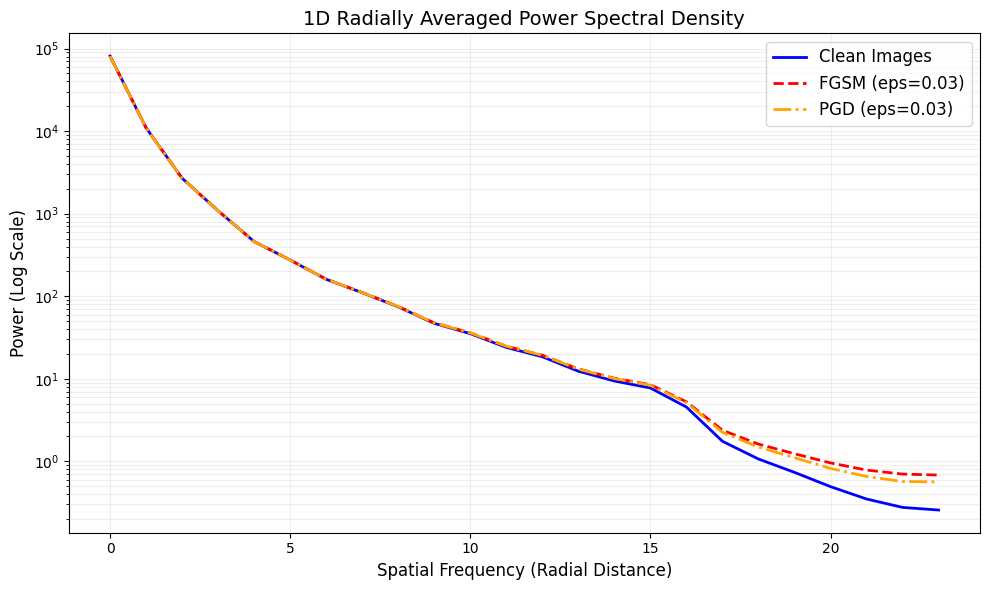

In [9]:
plt.figure(figsize=(10, 6))

# The x-axis represents spatial frequency (radius from the center of the spectrum)
frequencies = np.arange(len(clean_psd))

plt.plot(frequencies, clean_psd, label="Clean Images", color="blue", linewidth=2)
plt.plot(
    frequencies,
    fgsm_psd,
    label="FGSM (eps=0.03)",
    color="red",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    frequencies,
    pgd_psd,
    label="PGD (eps=0.03)",
    color="orange",
    linestyle="-.",
    linewidth=2,
)

# Using a log scale for the Y-axis is standard for PSD as energy decays exponentially
plt.yscale("log")
plt.title("1D Radially Averaged Power Spectral Density", fontsize=14)
plt.xlabel("Spatial Frequency (Radial Distance)", fontsize=12)
plt.ylabel("Power (Log Scale)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("../datasets/adversarial/psd_comparison.png", dpi=300)
plt.show()